# **Machine Learning Part 2**

We will start by importing all of the necessary libraries for this workshop.

In [ ]:
import torch
import kagglehub

## **Convolutional Neural Networks**

In the earlier workshop, we built a linear regression model from scratch in order to accurately predict housing prices based on variables such as area. While this model worked well to identify patterns within that specific dataset, it may be too simple to fit to a more complicated task.

One task too complicated for a linear model is object detection. This is a problem that we deal with when handling the perception part of our system. Our vehicle must be able to detect what objects are in front of it to make critical decisions, such as when to brake. One type of model that might do better is a **Convolutional Neural Network**.



### **Neural Networks**

Before we discuss Convolutional Neural Networks we should first introduce what a neural network is. You have already seen a neural network before. The Linear Regression model that we trained in the last notebook is an example of a neural network.

A **neural network** looks like this

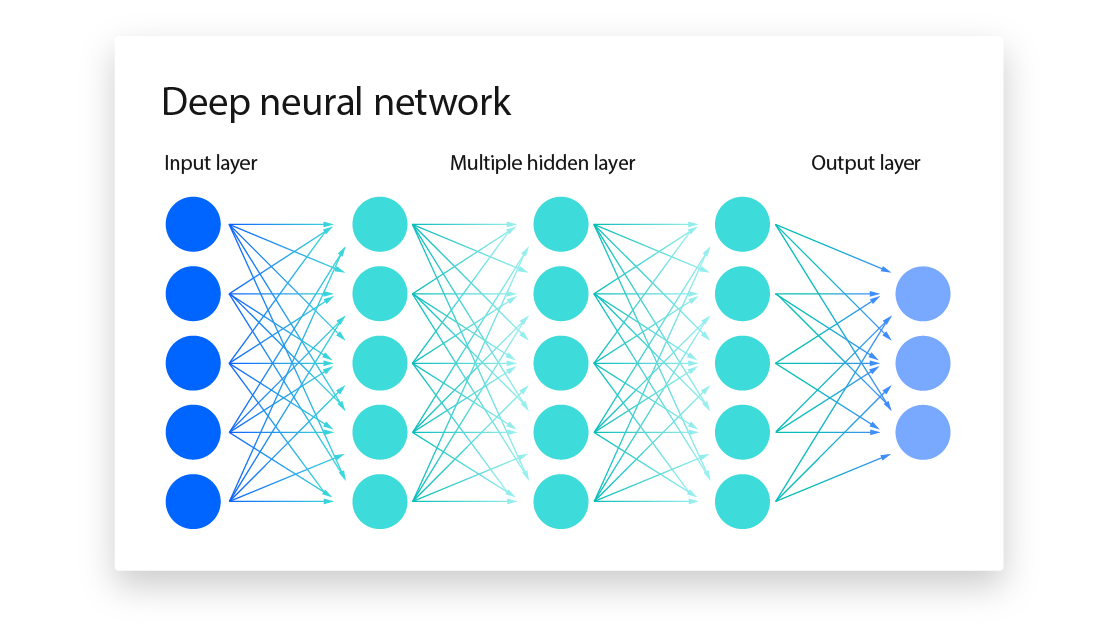

Each of the circles in the image is called a **neuron**. These often consist of a set of weights $w$ where $w$ is some weight vector. When the neuron takes in an input vector (this is either from the output of the neurons in the earlier layer) it performs $\sigma (w^{T}x + b)$ where $\sigma$ is some function (mostly a nonlinear function), $x$ is the input vector, and $b$ is some bias term. As you can see in the image above, each neuron in one layer is connected to every neuron in the next.

---
**Nonlinearity**

In the earlier formulation of the neuron operation, we saw that the neuron applies some nonlinearity after the matrix multiplication. **Why does it do this?**

Suppose we don't have any nonlinearities in the neural network, our neural network will then reduce to a function like $w^{T}x + b$ where $w$ is some set of weights in a matrix or vector form and $b$ is some vector. Hold on, we have seen this before. This is just the **linear regression model** all over again. That means that without any nonlinear functions, the best type of model that we can learn is a linear model. This is not good for more complex tasks that we are interested in (like the object detection task).

**Nonlinearity Examples:**

Some examples of nonlinear functions used are:

- ReLU: https://en.wikipedia.org/wiki/Rectified_linear_unit
- ELU: https://en.wikipedia.org/wiki/Rectified_linear_unit#ELU
- Softplus: https://en.wikipedia.org/wiki/Softplus

---
**Forward Pass**

In the image above, our forward pass would look something like this:


<center> input layer → hidden layer 1 → hidden layer 2 → output layer </center>


$$
\begin{bmatrix} x_0 \\ x_1 \\ x_2 \\ \vdots \\ x_n \end{bmatrix} \rightarrow
ReLU(w^1x + b_1)\rightarrow
ReLU(w^2h^1 + b_2)\rightarrow
Softmax(w^3h^2 + b_3)
$$

---
**Loss Function**

Following the forward pass, we need a way to determine how wrong we are. For multi-class classification examples, the traditional methodology is using **Cross-Entropy Loss**. This loss measures how confident the model was in the correct answer. Remember that following the softmax call in the forward pass, we generated a vector of probabilities for each class. This loss function is simply the negative log of the probability assigned to the true class:

$$
\mathcal{L} = -\log(\hat{y}_{true})
$$

This results in a low loss when $\hat{y}_{true}$ is large and a very high loss when $\hat{y}_{true}$ is small.

---
**Back Propogation**

We now have our loss $\mathcal{L}$. We want to know how a subtle shift in our weight, w, impacts our loss. This is denoted as $\frac{\partial \mathcal{L}}{\partial w}$. By computing $\frac{\partial \mathcal{L}}{\partial w}$ for each weight, we know what direction to move our weights to minimize our loss.

$$
w_{new} = w - \alpha \frac{\partial \mathcal{L}}{\partial w}
$$

<center>and</center>

$$
b_{new} = b - \alpha \frac{\partial \mathcal{L}}{\partial b}
$$

where $\alpha$ is the learning rate.

Repeating this backpropogation step for many batches of inputs and across multiple epochs will result in a smaller overall $\mathcal{L}$.

---


##**So what sets apart a CNN?**

For object detection tasks, the input to our network will be a group of images. To properly classify what objects within the image are, we will rely heavily on **spatial relationships** between our pixels.

You might have noticed that a traditional neural network has no way to preserve these local relationships. If we have a 64 x 64 colored image, we would have to flatten it to produce our input vector of $64 * 64 * 3 = 12,288$ values. Now, two pixels (ie. (10, 12) and (11, 12)) which are neighboring and likely share some correlation, will be arbitrary entries in a vector and be treated as completely unrelated.

A **Convolutional Neural Network** solves this problem by focusing on local regions rather than the entire image. It does this through the convolution operation, which involves taking a small k x k grid and sliding it across the full H x W image. The result of the convolution operation is an output grid of size (W', H') where W' = (W - k + 1) and H' = (H - k + 1)

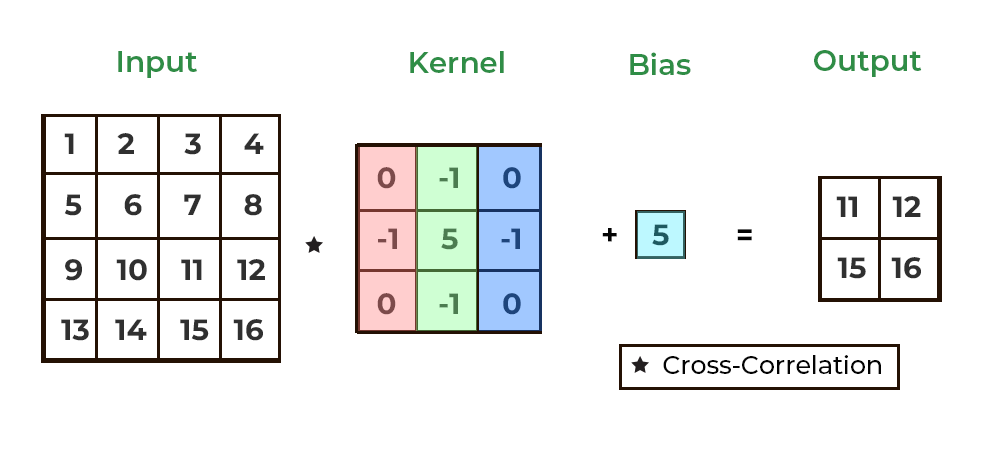
https://www.geeksforgeeks.org/computer-vision/apply-a-2d-convolution-operation-in-pytorch/$0

A kernel is used to identify a unique feature within our input image (ie. edge features, geometrics patterns, etc.). By applying N kernels to the same input image, we can create an output of size H' x W' x N. Simply put, a greater number of kernels means there are more features for our CNN to train on.

Applying this operation across multiple layers (called convolutional layers), we gradually decrease our spatial dimensions while increasing our depth (# of features).

## **Controlling Spatial Dimensions**

Though our convolution operation shrinks the spatial dimensions, it only does so marginally. To accelerate the convergence of our CNN, we need to decrease the spatial resolution more rapidly. We do this through the use of **Pooling** techniques, most commonly implemented as **MaxPooling2d**.

- MaxPooling2d reduces the spatial dimensions of our feature map by extracting the maximum value from a localized window (2x2 grid).

Once we sufficiently reduce our spatial dimensions, we flatten our vector of values and feed it into a traditional neural network (called the fully connected layer) which is used to produce our final classification results.

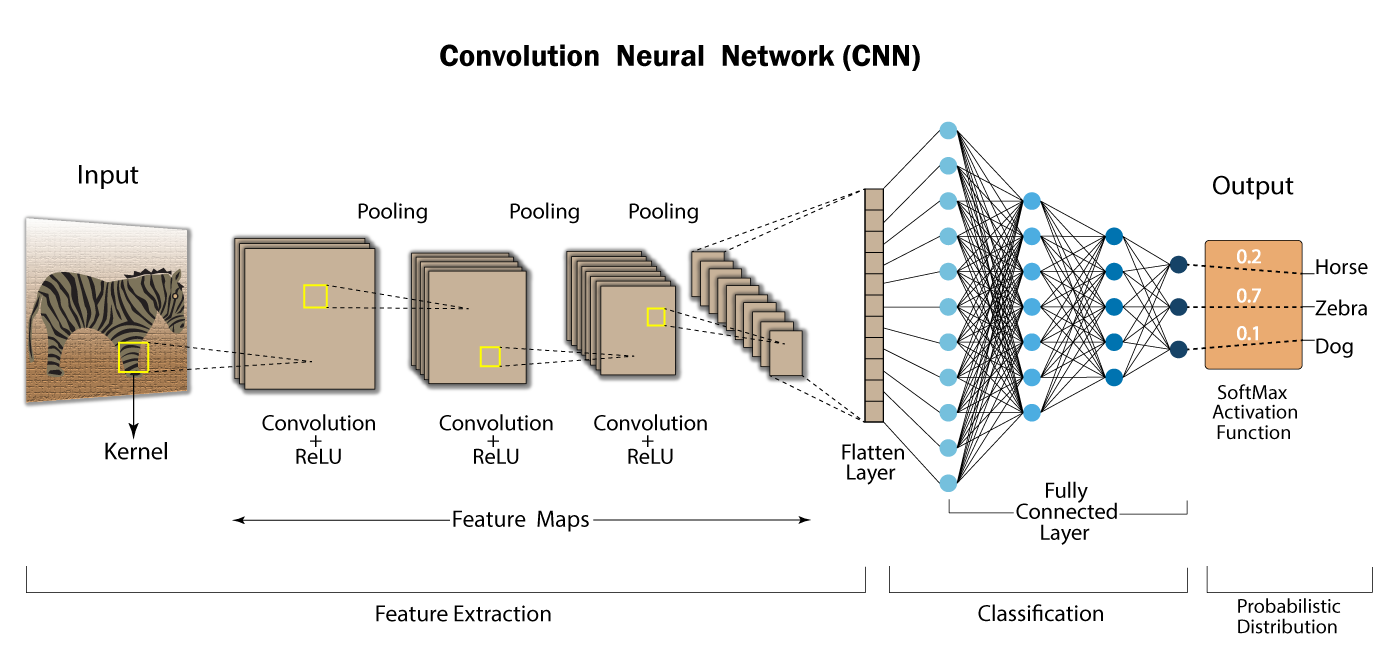
https://www.plainconcepts.com/convolutional-neural-network-guide/$0

## **Softmax**

The softmax function converts the output vector of un-normalized scores x into a valid probability distribution $\sigma$ defined as follows:

$$
\sigma_i = \frac{e^{x_i}}{\sum_{j=1}^{K} e^{x_j}}
$$





## **Implementing a CNN in PyTorch**

Now that we know the overall structure of a CNN, let's implement a basic deep learning model using PyTorch to identify hand-written digits.

**Some basic imports we will be using**

In [ ]:
import torch
import torchvision
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
import torchvision.transforms.v2 as v2
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torch.nn.functional as F
import pandas as pd
import torch.nn as nn
import torchvision.transforms as transforms

Download the MNIST dataset, which contains 60000 images of hand written numbers.

In [ ]:
scale_transformation = transforms.Compose([
    transforms.ToTensor()
])
mnist_dataset = MNIST(root='data/', download=True, transform=scale_transformation)
print(f"Successfully loaded {len(mnist_dataset)} samples from the MNIST dataset")

Lets take a look at what one of our images looks like.

In [ ]:
image, label = mnist_dataset[45]
plt.imshow(image[0], cmap='gray')
plt.title(f"Number: {label}")
plt.show()

Unfortunately, we can't directly load images into our PyTorch classifier. Instead, we have to first convert them into tensors. This can be done using a transfom function. Using the documentation below, re-load the dataset with the images stored as tensors.

https://docs.pytorch.org/tutorials/beginner/basics/transforms_tutorial.html$0



<details>
<summary>Hint</summary>
You will need to define the "transform" parameter within the MNIST call.
</details>

In [ ]:
mnist_dataset = MNIST(root='data/', download=True, transform=v2.ToImage())

In [ ]:
image_tens, label = mnist_dataset[45]
print(image_tens.shape, label)

Each image is 28x28, they are in grayscale which is why the first size element is 1. Go ahead and use `plt.imshow` to plot the image tensor. You will need to remove the first axis.

In [ ]:
plt.imshow("Your Code Here")

We can also see how our data samples are distributed amongst the different numbers 0-9.

In [ ]:
labels = mnist_dataset.targets.numpy()
df = pd.DataFrame(labels)
counts = df[0].value_counts()
plt.bar(counts.index, counts.values)
plt.title("Distribution of Data across Hand Written Numbers")
plt.xlabel("Number")
plt.ylabel("Count")
plt.show()


Great! Now that we successfully loaded and visualized our dataset, we need to divide our data into three different parts:
- **Training Set**: This is the data we will train our deep learning model on
- **Validation Set**: This is the data that we will evaluate the model on during training.
- **Testing Set**: This is the data we will use to evaluate our model at the end.

We can do this by using `random_split` which we imported above.

Go ahead and split the data such that 80% is in the training set, and the remaining 20% is in the test set.

<details>
<summary>Hint</summary>
The random_split function takes in the dataset and a list of integer values [train_samples, test_samples]
</details>

In [ ]:
train_samples = int(0.8 * len(mnist_dataset))
validation_samples = int(0.1 * len(mnist_dataset))
test_samples = len(mnist_dataset) - train_samples - validation_samples

train_set, val_set, test_set = random_split(mnist_dataset, [train_samples, validation_samples, test_samples])

print(f"Train set consists of {len(train_set)} samples")
print(f"Validation set consists of {len(val_set)} samples")
print(f"Test set consists of {len(test_set)} samples")


We are now going to place this data within **dataloaders**. Dataloaders allow us to manage how data is fed into our deep learning model. Here are a few of their features:
- **Batching**: Allows us to feed our data in small groups at a time (rather than one by one)
- **Shuffling**: We don't want our model to memorize the order of our dataset, dataloaders let us shuffle our data at the start of each epoch.
- **Parallel Processing**: Dataloaders can load your next batch of data in the background within the CPU, while the GPU focuses its power on training the current batch.

In [ ]:
training_dl = DataLoader(
    train_set,
    batch_size = 64, #This is a hyperparameter that can be changed
    shuffle = True,
    num_workers = 4
)

validation_dl = DataLoader(
    val_set,
    batch_size = 64,
    shuffle = True
)

testing_dl = DataLoader(
    test_set,
    batch_size = 64,
    shuffle = True
)

Now that we have organized all of our data into DataLoaders for easy access during training, we will need to create a loss function so that our model is able to evaluate its performance.

In [ ]:
def calculate_loss(batch, labels, model):
  #Write function to calculate the loss of a batch
  pass


Finally, it is time to create the actual Convolutional Neural Network Model.

Here are some useful links to help you get started:
- https://docs.pytorch.org/docs/2.14/generated/torch.nn.Sequential.html
- https://docs.pytorch.org/docs/2.14/generated/torch.nn.Conv2d.html#torch.nn.Conv2d

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#Design your CNN here (make sure to attach it to device)

Now that you have initialized your model let's see its starting average validation loss.

In [ ]:
def calculate_validation_loss(validation_dl, model):
  '''
  Write a function that goes through the validation data and calculates/returns
  the average validation loss.
  '''
  pass

Yikes! That doesn't look good. Let's make a generate function that takes in an image and outputs the model's prediction for that image.

In [ ]:
def predict_image(image, model):
  #Write a function that predicts the label of the image
  pass

Now let's see a visual example of what the model is predicting.

In [ ]:
image, label = mnist_dataset[12]
plt.imshow(image[0], cmap='gray')
plt.title(f"Number: {label}")
plt.show()
#Remember we will need to scale the image down to get accurate model predictions
test_image = image.float()/255.0
test_image = test_image.to(device)
print(f"Model Prediction: {predict_image(test_image, model)}")

Ok. Now we can really see that our model is not able to guess the number. Now, let us train the model for the number detection task.

In [ ]:
#Write training loop here


Let's plot the training loss and validation loss plots to see how our training progressed

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#Plot training loss here

In [ ]:
#Plot validation loss here

We can also do a visual confirmation in the same way as earlier.

In [ ]:
image, label = mnist_dataset[45]
plt.imshow(image[0], cmap='gray')
plt.title(f"Number: {label}")
plt.show()
#Remember we will need to scale the image down to get accurate model predictions
test_image = image.float()/255.0
test_image = test_image.to(device)
print(f"Model Prediction: {predict_image(test_image, model)}")

Congratulations!! You have now trained a CNN model for digit detection.